In [46]:
# Importação de bibliotecas

import os # para executar comandos de diretório
from google.colab import drive # habilitar google drive no colab
drive.mount('/content/drive')

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
# Definir caminho e classes

dataset_path = "/content/drive/MyDrive/programacao/IA/senai/[PROGIAG 2612SG] - Programação em Inteligência Artificial Generativa/semana4/dataset_atividade3/dataset"

classes = ["defeito", "normal"]
img_size = 100

In [48]:
# Carregandos as imagens do dataset
# Convertendo  as imagens para o formato RGB.
# Normalizando os pixels dividindo os valores por 255.

X = []
y = []

for classe in classes:
    pasta_classe = os.path.join(dataset_path, classe)

    for arquivo in os.listdir(pasta_classe):
        caminho_img = os.path.join(pasta_classe, arquivo)

        # Ler imagem com OpenCV
        img = cv2.imread(caminho_img)

        # Verificar se a imagem foi carregada corretamente
        if img is None:
            continue

        # Converter de BGR para RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Redimensionar
        img = cv2.resize(img, (img_size, img_size))

        # Normalizar os pixels
        img = img / 255.0

        # Adicionar aos dados
        X.append(img)

        # Criar rótulo
        y.append(classes.index(classe))

In [49]:
# Transformando as imagens em arrays numpy

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (80, 100, 100, 3)
Formato de y: (80,)


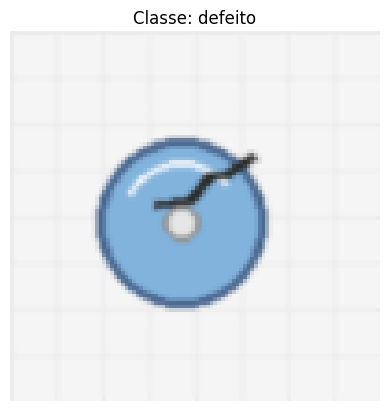

In [50]:
# Visualizando uma imagem

plt.imshow(X[0])
plt.title(f"Classe: {classes[y[0]]}")
plt.axis("off")
plt.show()

In [51]:
# Separando os dados em treinamento e teste

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (56, 100, 100, 3)
Teste: (24, 100, 100, 3)


In [52]:
# Criando a rede neural convulocional

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(img_size, img_size, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
# Compilando o modelo

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [54]:
# Treinando o modelo

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.4773 - loss: 1.4516 - val_accuracy: 0.7500 - val_loss: 0.6319
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.3864 - loss: 0.7222 - val_accuracy: 0.2500 - val_loss: 0.7209
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.4773 - loss: 0.6963 - val_accuracy: 0.2500 - val_loss: 0.7428
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.5682 - loss: 0.7136 - val_accuracy: 0.2500 - val_loss: 0.8315
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.5682 - loss: 0.6755 - val_accuracy: 0.2500 - val_loss: 0.7097
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.5682 - loss: 0.6843 - val_accuracy: 0.2500 - val_loss: 0.7298
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.5682 - loss: 0.6761 - val_accuracy: 0.3333 - val_loss: 0.7055
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.6818 - loss: 0.6568 - val_accuracy: 0.6667 - v

In [55]:
# Realizando prediçoes no conjunto de teste

y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


In [56]:
# Métricas de desemprennho

# Acurácia
from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia Geral do Modelo: {acuracia * 100:.2f}%")

Acurácia Geral do Modelo: 79.17%


In [57]:
# Matriz de confusão

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=classes))

[[ 7  5]
 [ 0 12]]
              precision    recall  f1-score   support

     defeito       1.00      0.58      0.74        12
      normal       0.71      1.00      0.83        12

    accuracy                           0.79        24
   macro avg       0.85      0.79      0.78        24
weighted avg       0.85      0.79      0.78        24



# Com poucas épocas, o modelo obteve apenas 50% de acurácia, Modificar o tamanho da imagem (img_size) nesta etapa não trouxe melhorias.
# O aumento para 100 épocas permitiu que a acurácia saltasse de 50% para 79,17%.
#Ao converter a escala dos pixels de 0–255 para 0.0–1.0, o intervalo numérico dos dados foi reduzido, sem essa etapa, o modelo provavelmente não teria estabilizado ou demoraria muito mais do que as 100 épocas para sair dos 50% de acurácia.
# A solução acima pode ser utilizada em processos de inspeção industrial, por exemplo, para inspecioanr a qualidade de um produto através de sistemas de visão computacional em tempo real.